In [ ]:
import polars as pl
import matplotlib.pyplot as plt

In [25]:
# data setup

df = pl.DataFrame({
    "team":   ["Duke","Arizona","Michigan","Florida","UConn","St. John's","Arkansas","Virginia","Houston","Iowa State","Vanderbilt","Michigan State","Purdue","Kansas","Gonzaga","Tennessee","Texas Tech","Illinois","Saint Mary's","Clemson","BYU","Louisville","Alabama","Missouri","TCU","Wisconsin","UCLA","VCU","Florida State","North Carolina","Utah State","Ohio State","NC State","Nebraska","Nevada","Texas A&M","Boise State","Indiana","UCF","Drake","Saint Louis","South Florida","George Mason","Dayton","Miami (OH)","Akron","Belmont","Tulsa","UNC Wilmington","Merrimack","Troy","Stephen F. Austin","McNeese","Siena","Yale","Cal Baptist","Penn","High Point","Tennessee State","Hawai'i","Prairie View A&M","Wright State","Kennesaw State","LIU","NDSU","Idaho","Lehigh","Queens Univ."],
    "seed":   [1,1,1,1,2,2,2,2,3,3,3,3,4,4,4,4,5,5,5,5,6,6,6,6,7,7,7,7,8,8,8,8,9,9,9,9,10,10,10,10,11,11,11,11,12,12,12,12,13,13,13,13,14,14,14,14,15,15,15,15,16,16,16,16,16,16,16,16],
    "region": ["East","West","Midwest","South","East","South","Midwest","West","West","East","South","Midwest","Midwest","West","East","South","South","East","West","Midwest","East","West","Midwest","South","West","South","East","Midwest","South","East","West","Midwest","Midwest","East","West","South","West","East","South","Midwest","Midwest","East","West","South","South","West","East","Midwest","Midwest","East","West","South","East","Midwest","West","South","Midwest","West","East","South","Midwest","West","South","East","Midwest","West","East","South"],
    "record": ["32-2","32-2","31-3","26-7","29-5","28-6","26-8","29-5","28-6","27-7","26-8","25-7","27-8","23-10","30-3","22-11","22-10","24-8","27-5","24-10","23-11","23-10","23-9","20-12","22-11","24-10","23-11","27-7","18-15","24-8","28-6","21-12","20-13","26-6","22-12","21-11","20-12","18-14","21-11","14-20","28-5","25-8","23-9","23-11","31-2","29-5","26-6","26-7","26-6","23-11","22-11","28-5","28-5","23-11","24-6","23-10","18-11","22-10","17-15","20-12","16-16","18-14","16-18","17-16","16-17","14-18","15-17","16-16"],
    "streak": ["W5","W3","L1","W12","W5","W2","W4","L1","W2","W1","L1","W2","W5","W1","W3","W1","W2","W2","W4","W1","W2","W1","W2","L2","W1","W2","W1","W3","W3","W1","W1","L1","L1","W1","W1","W1","L2","W2","W2","L2","W2","W4","W1","L1","L2","W1","W2","W2","W2","W2","W1","W3","W2","L1","L1","W1","W1","W2","W3","W2","W2","W1","W2","W1","W1","W1","W1","W1"],
})

In [26]:
df = df.with_columns(
    pl.col("streak")
    .str.replace("W", "")
    .str.replace("L", "-")
    .cast(pl.Int32)
    .alias("streak")
)

print(df.head(20))

shape: (20, 5)
┌──────────────┬──────┬─────────┬────────┬────────┐
│ team         ┆ seed ┆ region  ┆ record ┆ streak │
│ ---          ┆ ---  ┆ ---     ┆ ---    ┆ ---    │
│ str          ┆ i64  ┆ str     ┆ str    ┆ i32    │
╞══════════════╪══════╪═════════╪════════╪════════╡
│ Duke         ┆ 1    ┆ East    ┆ 32-2   ┆ 5      │
│ Arizona      ┆ 1    ┆ West    ┆ 32-2   ┆ 3      │
│ Michigan     ┆ 1    ┆ Midwest ┆ 31-3   ┆ -1     │
│ Florida      ┆ 1    ┆ South   ┆ 26-7   ┆ 12     │
│ UConn        ┆ 2    ┆ East    ┆ 29-5   ┆ 5      │
│ …            ┆ …    ┆ …       ┆ …      ┆ …      │
│ Tennessee    ┆ 4    ┆ South   ┆ 22-11  ┆ 1      │
│ Texas Tech   ┆ 5    ┆ South   ┆ 22-10  ┆ 2      │
│ Illinois     ┆ 5    ┆ East    ┆ 24-8   ┆ 2      │
│ Saint Mary's ┆ 5    ┆ West    ┆ 27-5   ┆ 4      │
│ Clemson      ┆ 5    ┆ Midwest ┆ 24-10  ┆ 1      │
└──────────────┴──────┴─────────┴────────┴────────┘


In [27]:
cinderella = df.filter(pl.col("seed") >= 9)
print(cinderella.head(20))

shape: (20, 5)
┌───────────────────┬──────┬─────────┬────────┬────────┐
│ team              ┆ seed ┆ region  ┆ record ┆ streak │
│ ---               ┆ ---  ┆ ---     ┆ ---    ┆ ---    │
│ str               ┆ i64  ┆ str     ┆ str    ┆ i32    │
╞═══════════════════╪══════╪═════════╪════════╪════════╡
│ NC State          ┆ 9    ┆ Midwest ┆ 20-13  ┆ -1     │
│ Nebraska          ┆ 9    ┆ East    ┆ 26-6   ┆ 1      │
│ Nevada            ┆ 9    ┆ West    ┆ 22-12  ┆ 1      │
│ Texas A&M         ┆ 9    ┆ South   ┆ 21-11  ┆ 1      │
│ Boise State       ┆ 10   ┆ West    ┆ 20-12  ┆ -2     │
│ …                 ┆ …    ┆ …       ┆ …      ┆ …      │
│ Tulsa             ┆ 12   ┆ Midwest ┆ 26-7   ┆ 2      │
│ UNC Wilmington    ┆ 13   ┆ Midwest ┆ 26-6   ┆ 2      │
│ Merrimack         ┆ 13   ┆ East    ┆ 23-11  ┆ 2      │
│ Troy              ┆ 13   ┆ West    ┆ 22-11  ┆ 1      │
│ Stephen F. Austin ┆ 13   ┆ South   ┆ 28-5   ┆ 3      │
└───────────────────┴──────┴─────────┴────────┴────────┘


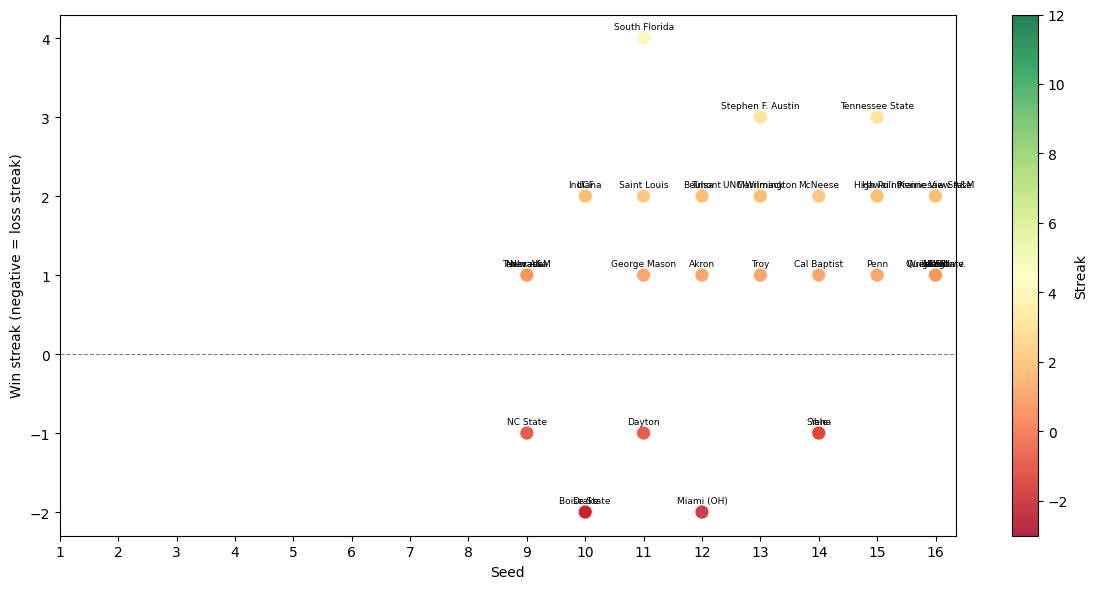

In [28]:

fig, ax = plt.subplots(figsize=(12, 6))

seeds   = cinderella["seed"].to_list()
streaks = cinderella["streak"].to_list()
names   = cinderella["team"].to_list()

scatter = ax.scatter(
    seeds, streaks,
    s=100,
    c=streaks,
    cmap="RdYlGn",
    vmin=-3,
    vmax=12,
    edgecolors="white",
    linewidths=0.5,
    alpha=0.85
)

for name, x, y in zip(names, seeds, streaks):
    ax.annotate(name, (x, y), fontsize=6.5, ha="center",
                va="bottom", textcoords="offset points", xytext=(0, 5))

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Seed")
ax.set_ylabel("Win streak (negative = loss streak)")
ax.set_xticks(range(1, 17))
plt.colorbar(scatter, ax=ax, label="Streak")
plt.tight_layout()
plt.show()